In [2]:
"imports"
import functions
import Interp3Dfield as tt
from neuron import h, gui
import numpy as np
import time
import datetime
import matplotlib.pyplot as plt
import scipy.io as sio
import os
import seaborn as sb
from matplotlib.colors import LinearSegmentedColormap
import mat73
from skimage import measure
import meshio
import gmsh
import trimesh
import stl
from scipy.spatial import cKDTree
import open3d as o3d
import pickle
from scipy.stats import ttest_ind, f_oneway, wilcoxon, shapiro, anderson, skew, variation
import pprint

	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	1 
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [ ]:
"loading in head model"
subject = 3
freq = '300Hz'


name1 = rf"\Exyz\s{subject}_{freq}.mat"
matf_FEM = mat73.loadmat(name1)
name2 = rf"Exyz_SPFD\s{subject}_{freq}_SPFD.mat"
matf_SPFD = mat73.loadmat(name2)

In [1]:
FEM_SPFD_comparison = {}

In [ ]:
"FEM vs SPFD"

for subject in [3,7,12,17,18,19,20,21,22,23,24]:
    for freq in ['300Hz','100kHz']:
        name1 = rf"Exyz\s{subject}_{freq}.mat"
        matf_FEM = mat73.loadmat(name1)
        name2 = rf"Exyz_SPFD\s{subject}_{freq}_SPFD.mat"
        matf_SPFD = mat73.loadmat(name2)
        for direction in ['anterior','superior','lateral']:
        
            E_FEM = np.sqrt(matf_FEM['E'][direction]['x']**2+matf_FEM['E'][direction]['y']**2+matf_FEM['E'][direction]['z']**2)
            E_SPFD = np.sqrt(matf_SPFD['E_SPFD'][direction]['x']**2+matf_SPFD['E_SPFD'][direction]['y']**2+matf_SPFD['E_SPFD'][direction]['z']**2)

            E_FEM_max = np.max(E_FEM)
            E_SPFD_max = np.max(E_SPFD)
            E_FEM_99 = np.percentile(E_FEM,99)
            E_SPFD_99 = np.percentile(E_SPFD,99)

            print(f'E_FEM_max = {E_FEM_max} | E_FEM_99 = {E_FEM_99}')
            print(f'E_SPFD_max = {E_SPFD_max} | E_SPFD_99 = {E_SPFD_99}')
            print(f'error_max = {np.abs((E_SPFD_max - E_FEM_max)/E_FEM_max)*100}% | error_99 = {np.abs((E_SPFD_99 - E_FEM_99)/E_FEM_99)*100}%')
            print('-'*10)
            if subject in FEM_SPFD_comparison:
                if freq in FEM_SPFD_comparison[subject]:
                    FEM_SPFD_comparison[subject][freq][direction] = {'E_FEM_max': E_FEM_max, 'E_SPFD_max': E_SPFD_max,\
                                                                      'E_FEM_99' : E_FEM_99,  'E_SPFD_99' : E_SPFD_99, \
                                                                        'error_max': np.abs((E_SPFD_max - E_FEM_max)/E_FEM_max)*100, \
                                                                            'error_99': np.abs((E_SPFD_99 - E_FEM_99)/E_FEM_99)*100}
                else:
                    FEM_SPFD_comparison[subject][freq] = {direction: {'E_FEM_max': E_FEM_max, 'E_SPFD_max': E_SPFD_max,\
                                                                      'E_FEM_99' : E_FEM_99,  'E_SPFD_99' : E_SPFD_99, \
                                                                        'error_max': np.abs((E_SPFD_max - E_FEM_max)/E_FEM_max)*100, \
                                                                            'error_99': np.abs((E_SPFD_99 - E_FEM_99)/E_FEM_99)*100}}

            else:
                FEM_SPFD_comparison[subject] = {freq: {direction: {'E_FEM_max': E_FEM_max, 'E_SPFD_max': E_SPFD_max,\
                                                                    'E_FEM_99' : E_FEM_99,  'E_SPFD_99' : E_SPFD_99, \
                                                                    'error_max': np.abs((E_SPFD_max - E_FEM_max)/E_FEM_max)*100, \
                                                                        'error_99': np.abs((E_SPFD_99 - E_FEM_99)/E_FEM_99)*100}}}

with open(rf"results\E_FEM_vs_E_SPFD.pkl",'wb') as pf:
    pickle.dump(FEM_SPFD_comparison,pf)

24 300Hz anterior
E_FEM_max = 0.9902346730232239 | E_FEM_99 = 0.16684224665164926
E_SPFD_max = 0.9143206477165222 | E_SPFD_99 = 0.16535797789692852
error_max = 7.666265964508057% | error_99 = 0.8896240517665487%
----------
24 300Hz superior
E_FEM_max = 0.6102158427238464 | E_FEM_99 = 0.1254878227412699
E_SPFD_max = 0.5906203389167786 | E_SPFD_99 = 0.12447487123310563
error_max = 3.211241587996483% | error_99 = 0.8072109994710565%
----------
24 300Hz lateral
E_FEM_max = 1.50086510181427 | E_FEM_99 = 0.24404652759432777
E_SPFD_max = 1.4386900663375854 | E_SPFD_99 = 0.24068330228328705
error_max = 4.142613336443901% | error_99 = 1.3781082419788906%
----------
24 100kHz anterior
E_FEM_max = 343.6311340332031 | E_FEM_99 = 56.1276176452634
E_SPFD_max = 313.8927307128906 | E_SPFD_99 = 55.554474754333455
error_max = 8.654164522886276% | error_99 = 1.0211423804806925%
----------
24 100kHz superior
E_FEM_max = 216.7791290283203 | E_FEM_99 = 42.144645004272434
E_SPFD_max = 208.03236389160156 | E_

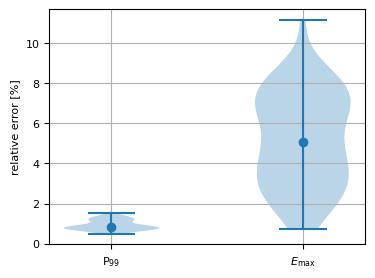

: 

In [ ]:
with open(rf"results\E_FEM_vs_E_SPFD.pkl",'rb') as pf:
    FEM_SPFD_comparison = pickle.load(pf)
errors_max = np.empty(66)
errors_99 = np.empty(66)

i = 0
for subject in [3,7,12,17,18,19,20,21,22,23,24]:
    for freq in ['300Hz','100kHz']:
        for direction in ['anterior','superior','lateral']:
            errors_max[i] = FEM_SPFD_comparison[subject][freq][direction]['error_max']
            errors_99[i] = FEM_SPFD_comparison[subject][freq][direction]['error_99']
            i+=1
plt.violinplot([errors_99,errors_max])
plt.scatter([1,2],[np.median(errors_99),np.median(errors_max)])
#plt.ylabel('relative error SPFD vs FEM [%]',fontsize=12)
plt.ylabel('relative error [%]',fontsize=8)
plt.xticks([1,2],[r'$\mathrm{P_{99}}$', r'$E_\mathrm{{max}}$'],fontsize=8)
plt.yticks(fontsize=8)
plt.grid()
plt.tight_layout()
plt.show()

330 429 488


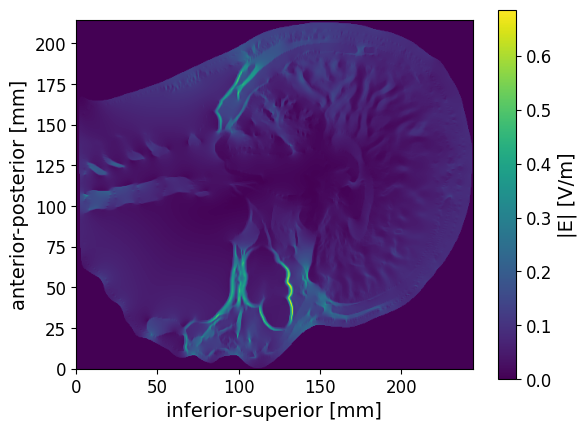

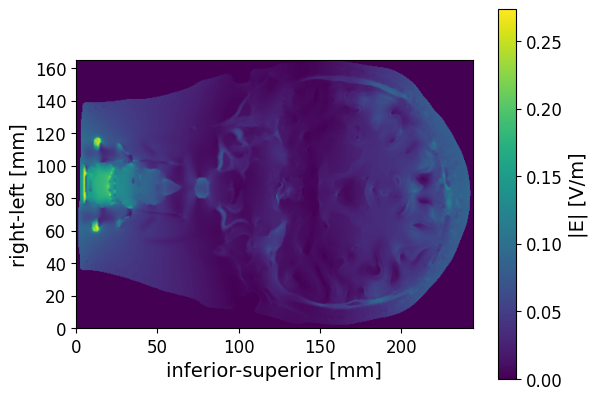

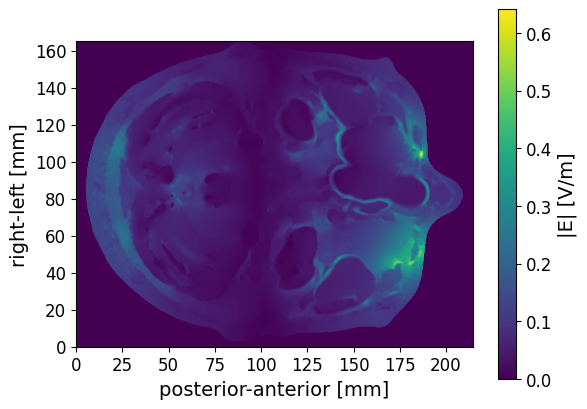

In [ ]:
"plotting E-field distribution"
#print(matf.keys())
Exlat, Eylat, Ezlat = matf_SPFD['E_SPFD'][direction]['x'], matf_SPFD['E_SPFD'][direction]['y'], matf_SPFD['E_SPFD'][direction]['z']
Emaglat = np.sqrt(Exlat**2+Eylat**2+Ezlat**2)[:,:,:]
lenx, leny, lenz = Emaglat.shape
print(lenx,leny,lenz)

plt.imshow(Emaglat[lenx//2,:,:],extent=[0,lenz*0.5,0,leny*0.5]) #
cbar = plt.colorbar()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('inferior-superior [mm]',fontsize = 14)
plt.ylabel('anterior-posterior [mm]',fontsize = 14)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('|E| [V/m]',fontsize=14)
#cbar.ax.yaxis.set_label_coords(10, 0.5)
plt.show()

plt.imshow(Emaglat[:,leny//2,:],extent=[0,lenz*0.5,0,lenx*0.5]) #
cbar = plt.colorbar()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('inferior-superior [mm]',fontsize = 14)
plt.ylabel('right-left [mm]',fontsize = 14)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('|E| [V/m]',fontsize=14)
#cbar.ax.yaxis.set_label_coords(10, 0.5)
plt.show()

plt.imshow(Emaglat[:,:,lenz//2],extent=[0,leny*0.5,0,lenx*0.5]) #
cbar = plt.colorbar()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('posterior-anterior [mm]',fontsize = 14)
plt.ylabel('right-left [mm]',fontsize = 14)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('|E| [V/m]',fontsize=14)
#cbar.ax.yaxis.set_label_coords(10, 0.5)
plt.show()

brainmap = matf_FEM['TissueTypeIndices']
braintissues = matf_FEM['name']
braintissuess = [['Environment']]+braintissues
brainmap.shape
#print(np.min(brainmap),np.max(brainmap))
#print(braintissuess)
Emaglat_GM = (Emaglat*(brainmap==16)).flatten()
Emaglat_GM_filtered = Emaglat_GM[Emaglat_GM!=0]


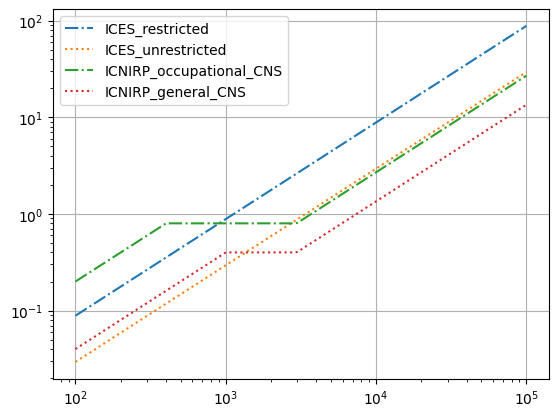

In [14]:
def plot_guidelines():
    freq_array = np.logspace(2,5,200) #np.logspace(2,5,200) #10 points is used so safety factors can be compared with simulation results

    #ICES
    E0_unres = 5.89*1e-3
    E0_res = 1.77*1e-2
    DRL_ICES_unres = np.array([E0_unres if freq < 20 else E0_unres*freq/20 for freq in freq_array])
    DRL_ICES_res = np.array([E0_res if freq < 20 else E0_res*freq/20 for freq in freq_array])
    #ICNIRP
    BS_ICNIRP_occ_CNS = np.array([0.5/freq if freq < 10 else 0.05 if freq <25 else 2*1e-3*freq if freq < 400 else 0.8 if freq < 3*1e3 else 2.7*1e-4*freq for freq in freq_array])
    #BS_ICNIRP_occ_PNS = np.array([0.8 if freq < 3*1e3 else 2.7*1e-4*freq for freq in freq_array])
    BS_ICNIRP_gen_CNS = np.array([0.1/freq if freq < 10 else 0.01 if freq <25 else 4*1e-4*freq if freq < 1000 else 0.4 if freq < 3*1e3 else 1.35*1e-4*freq for freq in freq_array])
    #BS_ICNIRP_gen_PNS = np.array([0.4 if freq < 3*1e3 else 1.35*1e-4*freq for freq in freq_array])

    #guidelines plotting
    plt.loglog(freq_array,DRL_ICES_res,'-.',label='ICES_restricted') #occupational
    plt.loglog(freq_array,DRL_ICES_unres,':',label='ICES_unrestricted') #general
    plt.loglog(freq_array,BS_ICNIRP_occ_CNS,'-.',label='ICNIRP_occupational_CNS') #occupational CNS
    #plt.loglog(freq_array,BS_ICNIRP_occ_PNS,'-.',label='ICNIRP_occupational_PNS') #occupational PNS   
    plt.loglog(freq_array,BS_ICNIRP_gen_CNS,':',label='ICNIRP_general_CNS') #occupational CNS
    #plt.loglog(freq_array,BS_ICNIRP_gen_PNS,':',label='ICNIRP_general_PNS') #occupational PNS 
    plt.legend()
    plt.grid()

def give_guidelines(CNS=0):
    freq_array = np.logspace(2,5,10) #np.logspace(2,5,200) #10 points is used so safety factors can be compared with simulation results

    #ICES
    E0_unres = 5.89*1e-3
    E0_res = 1.77*1e-2
    DRL_ICES_unres = np.array([E0_unres if freq < 20 else E0_unres*freq/20 for freq in freq_array])
    DRL_ICES_res = np.array([E0_res if freq < 20 else E0_res*freq/20 for freq in freq_array])
    #ICNIRP
    BS_ICNIRP_occ_CNS = np.array([0.5/freq if freq < 10 else 0.05 if freq <25 else 2*1e-3*freq if freq < 400 else 0.8 if freq < 3*1e3 else 2.7*1e-4*freq for freq in freq_array])
    #BS_ICNIRP_occ_PNS = np.array([0.8 if freq < 3*1e3 else 2.7*1e-4*freq for freq in freq_array])
    BS_ICNIRP_gen_CNS = np.array([0.1/freq if freq < 10 else 0.01 if freq <25 else 4*1e-4*freq if freq < 1000 else 0.4 if freq < 3*1e3 else 1.35*1e-4*freq for freq in freq_array])
    #BS_ICNIRP_gen_PNS = np.array([0.4 if freq < 3*1e3 else 1.35*1e-4*freq for freq in freq_array])

    if CNS:
        return([DRL_ICES_unres,DRL_ICES_res,BS_ICNIRP_occ_CNS,BS_ICNIRP_gen_CNS])

    return np.max([DRL_ICES_unres,DRL_ICES_res,BS_ICNIRP_occ_CNS,BS_ICNIRP_gen_CNS],axis=0)

def safety_factor(guideline,freq):
    if guideline == 'DRL_ICES_unres':
        return 9
    elif guideline == 'DRL_ICES_res':
        return 3
    elif guideline == 'BS_ICNIRP_gen_CNS':
        return 5 if freq < 1e3 else 10
    elif guideline == 'BS_ICNIRP_occ_CNS':
        return 1 if freq < 400 else 5
    
plot_guidelines()


safety factors for ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25],[3, 7, 12, 17, 18, 19, 20, 21, 22, 23, 24],['lateral', 'superior', 'anterior', 'medial', 'inferior', 'posterior']): min_thresh/max_guidelines 
= [25.73712807 16.46347924 12.61883969 16.44811656 15.96846892 14.50793251
 11.35674601  8.76086948  6.14552321  4.6189075 ]
DRL_ICES_unres
[174.78525007 111.80631061  73.85118091  49.42812617  47.98674023
  43.59769193  34.12808225  26.32723086  18.46787109  13.88024834]
DRL_ICES_res
[58.16300129 37.2056028  24.57533647 16.44811656 15.96846892 14.50793251
 11.35674601  8.76086948  6.14552321  4.6189075 ]
BS_ICNIRP_occ_CNS
[25.73712807 16.46347924 12.61883969 18.19572895 38.05834463 47.55377879
 37.22488971 28.71618329 20.1436594  15.13975236]
BS_ICNIRP_gen_CNS
[128.68564036  82.31739619  54.37293194  36.39145789  76.11668926
  95.10755759  74.44977942  57.43236658  40.2873188   30.27950472]


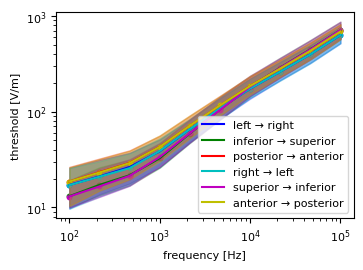

(6, 25, 11, 10, 10)
(2750, 10)
slat: [ 12.01094487  13.60497889  15.35150354  19.95940552  27.13681038
  39.77460244  60.03369507  83.91875672 125.89048387 188.07657547]
ssup: [ 11.68291923  12.59062571  13.96331559  17.56345549  26.95630199
  44.74521795  69.71175744 102.83394225 149.45356631 223.52152724]
sant: [ 12.18951075  14.94385703  17.45838796  20.92681859  28.56288023
  40.67786652  56.01332898  82.08962092 122.80715976 185.03987801]
['anterior', 'anterior', 'anterior', 'anterior', 'anterior', 'superior', 'superior', 'superior', 'superior', 'superior']


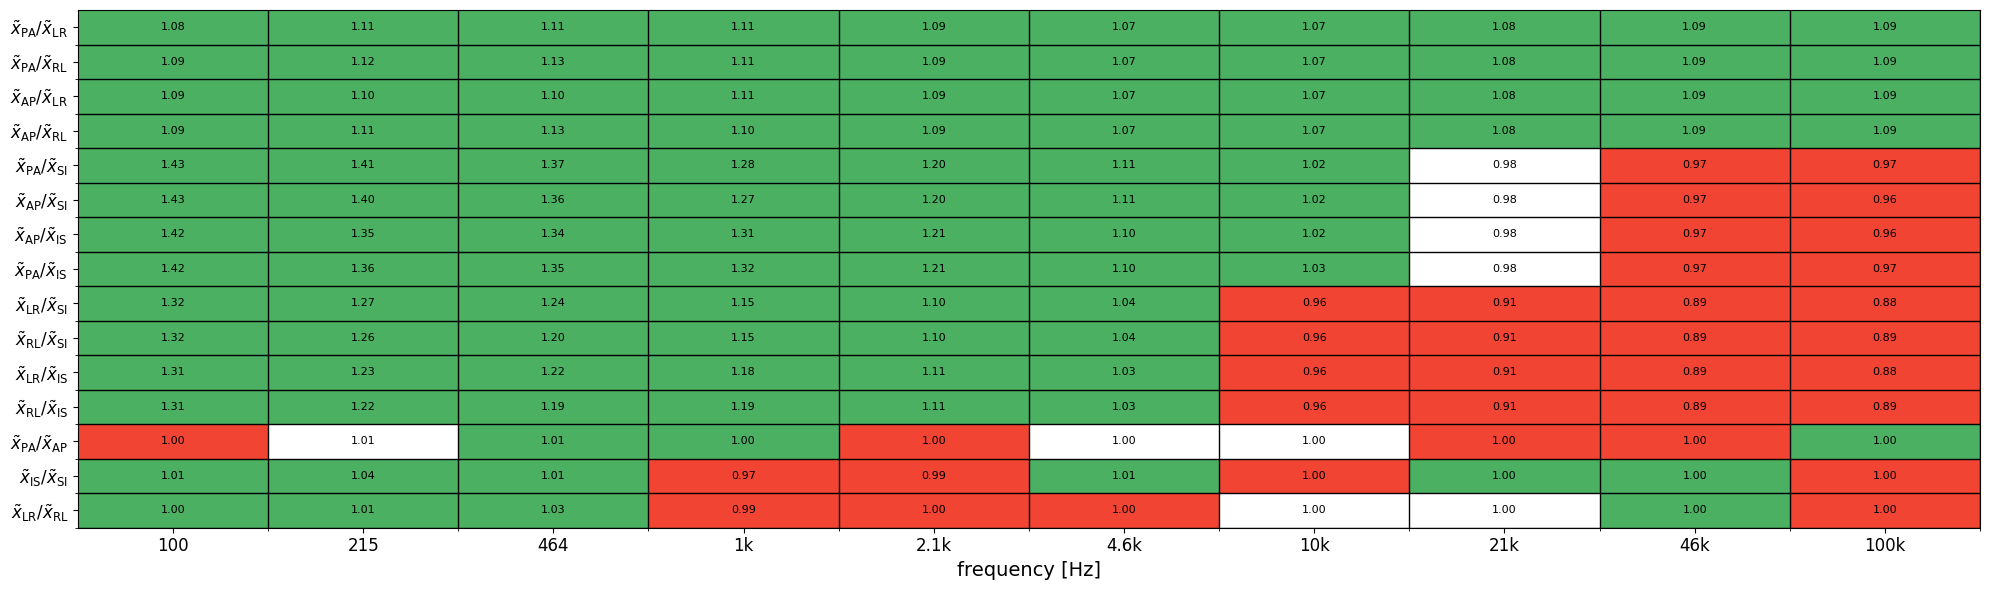

In [ ]:

"""direction variations"""

cells = [cel for cel in range(1,26)]
subjects = [3,7,12,17,18,19,20,21,22,23,24]
directions = ['lateral', 'superior', 'anterior'] + ['medial', 'inferior', 'posterior']
#cells = [1,2,3,4,5,6,7,8,9,10,11,15,16,20,21,22,23,24,25] #cells[0:5] + cells[5:10] + cells[10:11] + cells[15:16] + cells[20:25] #[1,2,3,4,5], [6,7,8,9,10], [11,12,13,14,15], [16,17,18,19,20], [21,22,23,24,25]
len_loc = 10
len_freq = 10
direction_map = {'lateral' : 'left → right', 'anterior' : 'posterior → anterior', 'superior' : 'inferior → superior', 'medial' : 'right → left', 'posterior' : 'anterior → posterior', 'inferior' : 'superior → inferior'}

colors = ['b','g','r','c','m','y','tab:orange','tab:pink','tab:brown','k']
#colors = ['b','y','r','g','c']
type1, type2, type3, type4, type5 = "L1 NGC-DA", "L2/3 PC", "L4 LBC", "L5 TTPC", "L6 TPC"
cell_names = [type1]*5 + [type2]*5 + [type3]*5 + [type4]*5 + [type5]*5
i = 0

all_freqs, all_threshs = np.empty((len(directions),len(cells),len(subjects),len_loc,len_freq)), np.empty((len(directions),len(cells),len(subjects),len_loc,len_freq)) #directions, locations*subjects, frequencies
#all_freqs, all_threshs = np.empty((len(cells),len(directions),len(subjects),len_loc,len_freq)), np.empty((len(cells),len(directions),len(subjects),len_loc,len_freq)) #directions, locations*subjects, frequencies


for id,direction in enumerate(directions): # ic,cell in enumerate(cells) #id,direction in enumerate(directions)
    freqs, threshs = np.empty((len(cells),len(subjects),len_loc,len_freq)), np.empty((len(cells),len(subjects),len_loc,len_freq))
    #freqs, threshs = np.empty((len(directions),len(subjects),len_loc,len_freq)), np.empty((len(directions),len(subjects),len_loc,len_freq))
    for ic,cell in enumerate(cells): # id,direction in enumerate(directions) #ic,cell in enumerate(cells)
        for isub, subject in enumerate(subjects): #isub, subject in enumerate(subjects)
            with open(rf"results\SPFD\interpol_linear_logspace_(10, 2, 5)_cell_nr_{cell}_dt_fact_100_subject_{subject}_direction_{direction}.pkl",'rb') as f:
                pkl = pickle.load(f)
            hs300 = pkl['hotspot_300']
            hs100k = pkl['hotspot_100k']

            if sum(hs300[0]['location']==hs100k[0]['location']) == 3:
                for iloc,val300 in enumerate(hs300.values()): #10 locations
                    freq = val300['freq']
                    thresh = val300['thresh']/np.sqrt(2) #peak->RMS
                    freqs[ic,isub,iloc] = freq #ic,isub,iloc
                    threshs[ic,isub,iloc] = thresh
            else:
                for iloc, (val300, val100k) in enumerate(zip(hs300.values(),hs100k.values())): #10 locations
                    freq = val300['freq']
                    thresh = np.min((val300['thresh'], val100k['thresh']),axis=0)/np.sqrt(2) #peak->RMS
                    freqs[ic,isub,iloc] = freq
                    threshs[ic,isub,iloc] = thresh
    all_freqs[id] = freqs #id
    all_threshs[id] = threshs
    threshs_flat = threshs.reshape(-1,10)
    qmin = np.quantile(threshs_flat,1/4,axis=0)
    q50 = np.quantile(threshs_flat,2/4,axis=0)
    qmax = np.quantile(threshs_flat,3/4,axis=0)

    plt.scatter(freq,q50,c = colors[i],s=10)
    plt.plot(freq,q50,label=f'{direction_map[direction]}',color = colors[i]) #,color='r'
    plt.fill_between(freq,qmin,qmax,alpha=0.3,color = colors[i]) #,label=f'25-75 ({direction})'

    i+=1

min_thresh = np.min(threshs_flat,axis=0)
max_guidelines = give_guidelines()
print(f'\nsafety factors for ({cells},{subjects},{directions}): min_thresh/max_guidelines \n= {min_thresh/max_guidelines}')
guidelines = give_guidelines(CNS=1)
for guideline, name, fr in zip(guidelines, ['DRL_ICES_unres','DRL_ICES_res','BS_ICNIRP_occ_CNS','BS_ICNIRP_gen_CNS'], freq):
    #print(f' min_thresh/{name}: \n= {min_thresh/guideline}')
    print(name)
    sf = [safety_factor(name,fr) for fr in freq]
    print((min_thresh/guideline))
    #print(np.sum((min_thresh/guideline/sf)<1))

#plot_guidelines()
plt.grid()
plt.xlabel('frequency [Hz]',fontsize = 8)
plt.ylabel('threshold [V/m]',fontsize = 8)
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
plt.xscale('log')
plt.yscale('log')
plt.grid() 
plt.legend(loc='lower right',fontsize=8)
#plt.title(f'cells: {cells}, subjects: {subjects}, directions: {directions} exposure, 10 closest locations',fontsize=8)
fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.48/2,7.48*y_size/(2*x_size))
fig.tight_layout()
plt.show()

print(all_threshs.shape)
lat = (all_threshs[0]).reshape(-1,10)
sup = (all_threshs[1]).reshape(-1,10)
ant = (all_threshs[2]).reshape(-1,10)
med = (all_threshs[3]).reshape(-1,10)
inf = (all_threshs[4]).reshape(-1,10)
pos = (all_threshs[5]).reshape(-1,10)

print(lat.shape)

"violin plots"
violin = 0
if violin:
    for fr in range(10):
        violins = []
        for i,e in enumerate([lat,sup,ant,med,inf,pos]):
            violin = e[:,fr]
            violins += [violin]
            plt.scatter(i+1,np.median(violin))
            print(f"direction: {directions[i]}, mini: {np.min(violin)}, maxi: {np.max(violin)}, maxi/mini = {np.max(violin)/np.min(violin)}")
        maxmin = [np.max(e)/np.min(e) for e in violins]
        medians =  [np.median(e) for e in violins]
        mins =  [np.min(e) for e in violins]
        sorted_medians = np.array(directions)[np.argsort(medians)]
        sorted_mins = np.array(directions)[np.argsort(mins)]
        print(f"sorted medians: {sorted_medians}")
        print(f"sorted mins: {sorted_mins}")
        print(f"median_{sorted_medians[-1]}/median_{sorted_medians[0]} = {medians[np.argsort(medians)[-1]]} / {medians[np.argsort(medians)[0]]} = {medians[np.argsort(medians)[-1]] / medians[np.argsort(medians)[0]]}")
        print(f"sorted maxi/mini: {np.array(directions)[np.flip(np.argsort(maxmin))]}")
        plt.violinplot(violins)
        plt.yscale('log')
        plt.xticks([1,2,3,4,5,6],['lateral','superior','anterior','medial','inferior','posterior'])
        plt.grid()
        plt.title(f'frequency = {np.round(freq[fr])} Hz')
        plt.show()


"difference violin plots (only for the original 3 directions)"
diff_violin = 0
if diff_violin:
    for fr in range(10):
        violins = []
        for i,(e,f) in enumerate(zip([lat,sup,ant],[sup,ant,lat])):
            violin1 = e[:,fr]
            violin2 = f[:,fr]
            violindiff = violin1-violin2
            violins += [violindiff]
            plt.scatter(i+1,np.median(violindiff))
            print('symmetry:')
            print(f'mean:{np.mean(violindiff)}, median:{np.median(violindiff)}, relative error: {(np.mean(violindiff)-np.median(violindiff))/np.median(violindiff)}')
            print(f'skewness: {skew(violindiff)}')
        plt.violinplot(violins)
        plt.xticks([1,2,3],['lateral-superior','superior-anterior','anterior-lateral'])
        plt.grid()
        plt.title(f'frequency = {np.round(freq[fr])} Hz')
        plt.show()



slat = np.std(lat,axis=0)
ssup = np.std(sup,axis=0)
sant = np.std(ant,axis=0)
#ANOVA = f_oneway(lat,sup,ant,axis=0)
#print(ANOVA)
print(f'slat: {slat}')
print(f'ssup: {ssup}')
print(f'sant: {sant}')
print(['anterior' if (a > l and a > s) else 'lateral' if (l > a and l > s) else 'superior' if (s > a and s > l) else 0 for (a,l,s) in zip(sant,slat,ssup)])

p_values = np.empty((15,10))
bigger_thans = np.empty((15,10))
significances = np.empty((15,10))
medians = np.empty((15,10))

#for one-sided t-test
p_values2 = np.empty((15,2,10))
bigger_thans2 = np.empty((15,2,10))
significances2 = np.empty((15,2,10))

dir_dict = {str(ant): 'PA', str(sup): 'IS', str(lat): 'LR', str(pos): 'AP', str(inf): 'SI', str(med): 'RL'}

yticks = []
yticks2 = []

for i,(t1,t2) in enumerate(zip([ant,ant,pos,pos,ant,pos,pos,ant,lat,med,lat,med,ant,sup,lat],
                               [lat,med,lat,med,inf,inf,sup,sup,inf,inf,sup,sup,pos,inf,med])):
    ttest = wilcoxon(t1,t2) #gives the same result as wilcoxon(t2,t1)
    pvalue = ttest.pvalue
    p_values[i] = pvalue
    significant = np.where((pvalue > 0) & (pvalue <= 0.05), 1, 0)
    means = np.median(t1,axis=0) - np.median(t2,axis=0)
    median_ratio = np.median(t1,axis=0) / np.median(t2,axis=0)
    bigger_than = np.where(means > 0, 1, -1)
    significant_bigger_than = significant * bigger_than
    bigger_thans[i] = bigger_than
    medians[i] = median_ratio
    name1 = dir_dict[str(t1)]#.replace('-', r'\\text{-}')
    name2 = dir_dict[str(t2)]#.replace('-', r'\\text{-}')
    yticks += [fr'$\tilde{{x}}_{{\mathrm{{{name1}}}}} / \tilde{{x}}_{{\mathrm{{{name2}}}}}$']

#for one-sided t-test
for i,(t1,t2) in enumerate(zip([ant,ant,lat],[lat,sup,sup])):
    tt1 = wilcoxon(t1,t2,alternative='greater')
    tt2 = wilcoxon(t2,t1,alternative='greater')
    pvalue1 = tt1.pvalue
    pvalue2 = tt2.pvalue
    p_values2[i,0] = pvalue1
    p_values2[i,1] = pvalue2
    significant1 = np.where((pvalue1 > 0) & (pvalue1 <= 0.05), 1, 0)
    significant2 = np.where((pvalue2 > 0) & (pvalue2 <= 0.05), 1, 0)
    means1 = np.median(t1,axis=0) - np.median(t2,axis=0)
    means2 = np.median(t2,axis=0) - np.median(t1,axis=0)
    bigger_than1 = np.where(means > 0, 1, -1)
    bigger_than2 = np.where(means > 0, -1, 1)
    significant_bigger_than1 = significant1 * bigger_than1
    significant_bigger_than2 = significant2 * bigger_than2
    bigger_thans2[i,0] = bigger_than1
    bigger_thans2[i,1] = bigger_than2
    yticks2 += [f'{dir_dict[str(t1)]} > {dir_dict[str(t2)]}']
    yticks2 += [f'{dir_dict[str(t2)]} > {dir_dict[str(t1)]}']


redgreen = np.array([[0,1,2,3],[4,5,6,7]])
redgreen = np.array([[1,1,1,3],[5,5,5,7]]) 

for il,line in enumerate(significances):
    for iv,value in enumerate(line):
        irg = 0 if bigger_thans[il,iv] > 0 else 1
        jrg = 0 if p_values[il,iv] < 0.001 else 1 if p_values[il,iv] < 0.01 else 2 if p_values[il,iv] < 0.05 else 3
        significances[il,iv] = redgreen[irg,jrg]

#for one-sided t-test
for il,line in enumerate(significances):
    line1 = significances2[il,0]
    line2 = significances2[il,1]
    for iv,(value1,value2) in enumerate(zip(line1,line2)):
        irg = 0 if bigger_thans2[il,0,iv] > 0 else 1
        jrg = 0 if p_values2[il,0,iv] < 0.001 else 1 if p_values2[il,0,iv] < 0.01 else 2 if p_values2[il,0,iv] < 0.05 else 3
        significances2[il,0,iv] = redgreen[irg,jrg]
        irg = 0 if bigger_thans2[il,1,iv] > 0 else 1
        jrg = 0 if p_values2[il,1,iv] < 0.001 else 1 if p_values2[il,1,iv] < 0.01 else 2 if p_values2[il,1,iv] < 0.05 else 3
        significances2[il,1,iv] = redgreen[irg,jrg]

"plot two one-sided instead of two-sided"
# p_values = p_values2.reshape((-1,10))
# bigger_thans = bigger_thans2.reshape((-1,10))
# significances = significances2.reshape((-1,10))
# yticks = yticks2
        


from matplotlib.colors import ListedColormap

greens = plt.cm.Greens(np.linspace(0.4, 1, 4))  # lighter to darker green
reds = plt.cm.Reds(np.linspace(0.4, 1, 4))
greens[-1] = [1,1,1,0] 
reds[-1] = [1,1,1,0] 
colors = [*greens, *reds]  # use hex colors here, if desired.
cmap = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(20,6))
plt.imshow(significances, vmin=0, vmax=len(cmap.colors), cmap=cmap)
#plt.imshow(np.ones((6,10)), vmin=0, vmax=len(cmap.colors), cmap=cmap)



def sci_text_clean(x, sig=2):
    """
    Format number for Matplotlib with superscript using MathText.
    Removes leading zeros in exponent (e.g., 10^9 instead of 10^09; 10^-9 instead of 10^-09).
    """
    s = f"{x:.{sig}e}"              # e.g., '1.23e-09'
    mantissa, exp = s.split("e")

    # Clean mantissa: remove trailing zeros and decimal point if needed
    mantissa = mantissa.rstrip("0").rstrip(".") or "0"

    # Parse exponent: capture sign and digits separately
    sign = "-" if exp.startswith("-") else ""
    digits = exp.lstrip("+-")                # remove any sign
    digits = digits.lstrip("0") or "0"       # strip leading zeros from digits only
    power = f"{sign}{digits}" if digits != "0" else "0"
    return fr"{mantissa}×10$^{{{power}}}$"



ax.set_aspect('auto')
for i in range(len(significances)):
    for j in range(len(significances[0])):
        #val = p_values[i, j]
        val = medians[i, j]
        plt.text(
            #j, i, sci_text_clean(val, sig=2),
            j, i, f'{val:.2f}',
            ha="center", va="center",
            fontsize=8
        )
        #plt.text(j,i,sci_text_clean(p_values[i,j]),ha="center", va="center") #p-values are too long to show on a small square!





"plotting the colorbars"

import matplotlib.colors as mcolors

# Use the *lowest* shade for the arrow, and the next 3 shades for the bins
cmap = mcolors.ListedColormap(reds[1:])  # bins: reds[1], reds[2], reds[3]
cmap.set_under(reds[0])                  # arrow: reds[0], visually distinct

# Use the *lowest* shade for the arrow, and the next 3 shades for the bins
cmap2 = mcolors.ListedColormap(greens[1:])  # bins: reds[1], reds[2], reds[3]
cmap2.set_under(greens[0])                  # arrow: reds[0], visually distinct

# Boundaries define 3 bins and an 'under' region for the arrow
boundaries = [0.001, 0.01, 0.05, 1.0]    # 3 bins
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

plt.yticks([e for e in range(len(yticks))],yticks,fontsize=12)
plt.yticks([e+0.5 for e in range(len(yticks))],minor=True,fontsize=12)
plt.xticks([e for e in range(10)],['100', '215', '464', '1k', '2.1k', '4.6k', '10k', '21k', '46k', '100k'],fontsize=12)
plt.xticks([e+0.5 for e in range(10)],minor=True,fontsize=12)
plt.xlabel('frequency [Hz]',fontsize=14)
plt.grid(which='minor', color='black', linestyle='-', linewidth=1)
plt.tight_layout()
plt.show()

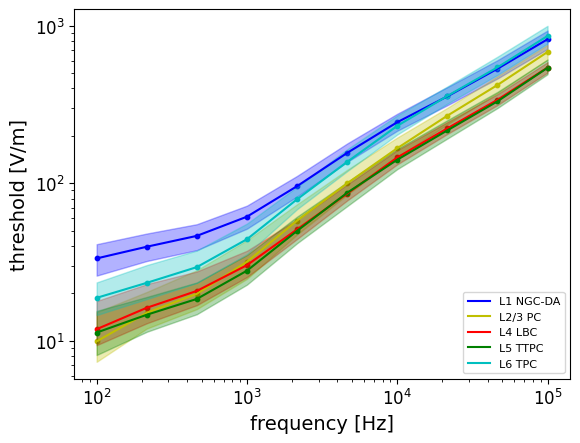

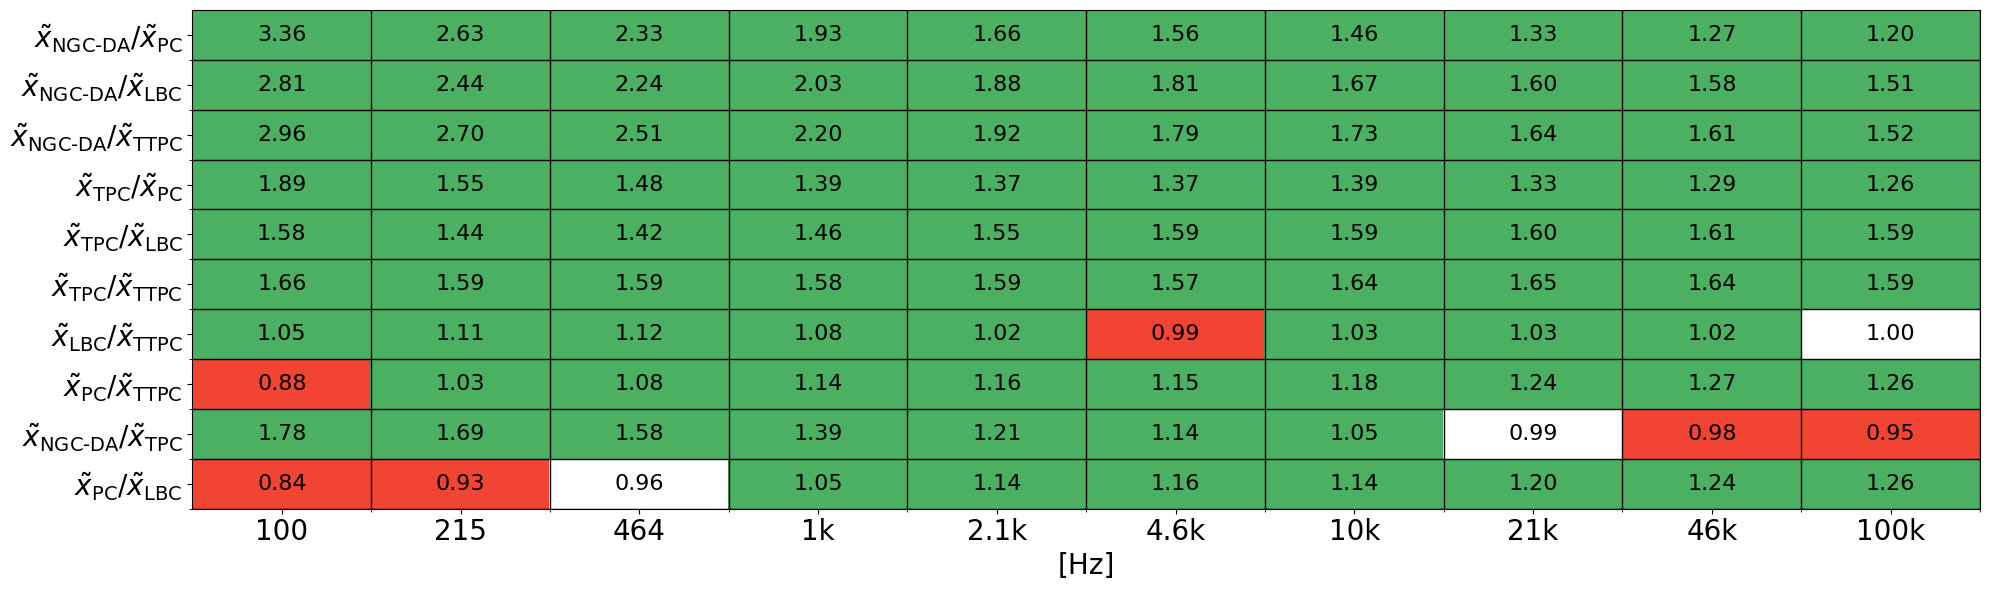

In [ ]:
"""cell variations"""

subjects = [3,7,12,17,18,19,20,21,22,23,24]
directions = ['lateral', 'superior', 'anterior']
len_loc = 10
len_freq = 10
len_celltypes = 5
len_cellclones = 5
cells = [5*celltype + cellclone + 1 for celltype in range(len_celltypes) for cellclone in range(len_cellclones)]

colors = ['b','g','r','c','m','y','tab:orange','tab:pink','tab:brown','k']
colors = ['b','y','r','g','c']
type1, type2, type3, type4, type5 = "L1 NGC-DA", "L2/3 PC", "L4 LBC", "L5 TTPC", "L6 TPC"
celltypes = [type1, type2, type3, type4, type5]
cell_names = [type1]*5 + [type2]*5 + [type3]*5 + [type4]*5 + [type5]*5
i = 0

all_freqs, all_threshs = np.empty((len_celltypes,len_cellclones,len(directions),len(subjects),len_loc,len_freq)), np.empty((len_celltypes,len_cellclones,len(directions),len(subjects),len_loc,len_freq))

with open('thresholds.csv','w') as th:

    for ict,celltype in enumerate(range(len_celltypes)):
        for icc,cellclone in enumerate(range(len_cellclones)):
            freqs, threshs = np.empty((len(directions),len(subjects),len_loc,len_freq)), np.empty((len(directions),len(subjects),len_loc,len_freq))
            for id,direction in enumerate(directions):
                for isub, subject in enumerate(subjects): 
                    with open(rf"results\SPFD\interpol_linear_logspace_(10, 2, 5)_cell_nr_{5*celltype+cellclone+1}_dt_fact_100_subject_{subject}_direction_{direction}.pkl",'rb') as f:
                        pkl = pickle.load(f)
                    hs300 = pkl['hotspot_300']
                    hs100k = pkl['hotspot_100k']

                    if sum(hs300[0]['location']==hs100k[0]['location']) == 3:
                        for iloc,val300 in enumerate(hs300.values()): #10 locations
                            freq = val300['freq']
                            thresh = val300['thresh']/np.sqrt(2) #peak->RMS
                            freqs[id,isub,iloc] = freq #ic,isub,iloc
                            threshs[id,isub,iloc] = thresh
                    else:
                        for iloc, (val300, val100k) in enumerate(zip(hs300.values(),hs100k.values())): #10 locations
                            freq = val300['freq']
                            thresh = np.min((val300['thresh'], val100k['thresh']),axis=0)/np.sqrt(2) #peak->RMS
                            freqs[id,isub,iloc] = freq
                            threshs[id,isub,iloc] = thresh
                    for fr, thr in zip(freq, thresh):
                        th.write(f'{subject}, {5*celltype+cellclone+1}, {direction}, {fr},{thr}\n')
            all_freqs[ict,icc] = freqs #id
            all_threshs[ict,icc] = threshs
        
        threshs_flat = all_threshs[ict].reshape(-1,10)
        qmin = np.quantile(threshs_flat,1/4,axis=0)
        q50 = np.quantile(threshs_flat,2/4,axis=0)
        qmax = np.quantile(threshs_flat,3/4,axis=0)

        plt.scatter(freq,q50,c = colors[i],s=10)
        plt.plot(freq,q50,label=f'{celltypes[ict]}',color = colors[i]) #,color='r'
        plt.fill_between(freq,qmin,qmax,alpha=0.3,color = colors[i]) #,label=f'25-75 ({celltypes[ict]})'
        i+=1

#plot_guidelines()
plt.grid()
plt.xlabel('frequency [Hz]',fontsize = 14)
plt.ylabel('threshold [V/m]',fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.xscale('log')
plt.yscale('log')
plt.grid() 
plt.legend(loc='lower right',fontsize=8)
#plt.title(f'cells: {cells}, subjects: {subjects}, directions: {directions} exposure, 10 closest locations',fontsize=8)
plt.show()


cell1 = (all_threshs[0]).reshape(-1,10)
cell23 = (all_threshs[1]).reshape(-1,10)
cell4 = (all_threshs[2]).reshape(-1,10)
cell5 = (all_threshs[3]).reshape(-1,10)
cell6 = (all_threshs[4]).reshape(-1,10)

"violin plots"
violin = 0
if violin:
    for fr in range(10):
        violins = []
        for i,e in enumerate([cell1,cell23,cell4,cell5,cell6]):
            violin = e[:,fr]
            violins += [violin]
            plt.scatter(i+1,np.median(violin))
            #print(f"cell: {celltypes[i]}, mini: {np.min(violin)}, maxi: {np.max(violin)}, maxi/mini = {np.max(violin)/np.min(violin)}")
            #print('normality:')
            #print(f"shapiro: {shapiro(violin)}")
            #print(f"anderson: {anderson(x=violin,dist='norm')}")
        maxmin = [np.max(e)/np.min(e) for e in violins]
        medians =  [np.median(e) for e in violins]
        mins = [np.min(e) for e in violins]
        sorted_medians = np.array(celltypes)[np.argsort(medians)]
        sorted_mins = np.array(celltypes)[np.argsort(mins)]
        print(f"sorted medians: {sorted_medians}")
        print(f"sorted mins: {sorted_mins}")
        print(f"median_{sorted_medians[-1]}/median_{sorted_medians[0]} = {medians[np.argsort(medians)[-1]]} / {medians[np.argsort(medians)[0]]} = {medians[np.argsort(medians)[-1]] / medians[np.argsort(medians)[0]]}")
        print(f"sorted maxi/mini: {np.array(celltypes)[np.flip(np.argsort(maxmin))]}")
        plt.violinplot(violins)
        plt.yscale('log')
        plt.xticks([1,2,3,4,5],['NGC-DA','PC','LBC','TTPC','TPC'])
        plt.grid()
        plt.title(f'frequency = {np.round(freq[fr])} Hz')
        plt.show()

p_values = np.empty((10,10))
bigger_thans = np.empty((10,10))
significances = np.empty((10,10))
medians = np.empty((10,10))

cell_dict = {str(cell1): 'NGC-DA', str(cell23): 'PC', str(cell4): 'LBC', str(cell5): 'TTPC', str(cell6): 'TPC'}

yticks = []
for i,(t1,t2) in enumerate(zip([cell1,cell1,cell1,cell6,cell6,cell6,cell4,cell23,cell1,cell23],[cell23,cell4,cell5,cell23,cell4,cell5,cell5,cell5,cell6,cell4])):
    ttest = wilcoxon(t1,t2) #gives the same result as wilcoxon(t2,t1)
    pvalue = ttest.pvalue
    p_values[i] = pvalue
    significant = np.where((pvalue <= 0.05), 1, 0)
    means = np.median(t1,axis=0) - np.median(t2,axis=0)
    median_ratio = np.median(t1,axis=0) / np.median(t2,axis=0)
    bigger_than = np.where(means > 0, 1, -1)
    significant_bigger_than = significant * bigger_than
    bigger_thans[i] = bigger_than
    medians[i] = median_ratio #median_ratio #means
    #yticks += [f'{cell_dict[str(t1)]} > {cell_dict[str(t2)]}']
    name1 = cell_dict[str(t1)].replace('-', r'\text{-}')
    name2 = cell_dict[str(t2)].replace('-', r'\text{-}')
    yticks += [rf'$\tilde{{x}}_{{\mathrm{{{name1}}}}} / \tilde{{x}}_{{\mathrm{{{name2}}}}}$'] 

redgreen = np.array([[0,1,2,3],[4,5,6,7]])
redgreen = np.array([[1,1,1,3],[5,5,5,7]]) 

for il,line in enumerate(significances):
    for iv,value in enumerate(line):
        irg = 0 if bigger_thans[il,iv] > 0 else 1
        jrg = 0 if p_values[il,iv] < 0.001 else 1 if p_values[il,iv] < 0.01 else 2 if p_values[il,iv] < 0.05 else 3
        significances[il,iv] = redgreen[irg,jrg]


from matplotlib.colors import ListedColormap

greens = plt.cm.Greens(np.linspace(0.4, 1, 4))  # lighter to darker green
reds = plt.cm.Reds(np.linspace(0.4, 1, 4))
greens[-1] = [1,1,1,0] 
reds[-1] = [1,1,1,0] 
colors = [*greens, *reds, "violet", "blue", 
          "turquoise", "limegreen", "gold", "brown"]  # use hex colors here, if desired.
cmap = ListedColormap(colors)



fig, ax = plt.subplots(figsize=(20,6))
plt.imshow(significances, vmin=0, vmax=len(cmap.colors), cmap=cmap)

def sci_text_clean(x, sig=2):
    """
    Format number for Matplotlib with superscript using MathText.
    Removes leading zeros in exponent (e.g., 10^9 instead of 10^09; 10^-9 instead of 10^-09).
    """
    s = f"{x:.{sig}e}"              # e.g., '1.23e-09'
    mantissa, exp = s.split("e")

    # Clean mantissa: remove trailing zeros and decimal point if needed
    mantissa = mantissa.rstrip("0").rstrip(".") or "0"

    # Parse exponent: capture sign and digits separately
    sign = "-" if exp.startswith("-") else ""
    digits = exp.lstrip("+-")                # remove any sign
    digits = digits.lstrip("0") or "0"       # strip leading zeros from digits only
    power = f"{sign}{digits}" if digits != "0" else "0"
    return fr"{mantissa}×10$^{{{power}}}$"



ax.set_aspect('auto')
# for i in range(len(significances)):
#     for j in range(len(significances[0])):
for i in range(len(medians)): 
    for j in range(len(medians[0])): 
        #val = p_values[i, j] 
        val = medians[i, j] 
        plt.text(
            # j, i, sci_text_clean(val, sig=2),
            j, i, f'{val:.2f}', 
            ha="center", va="center",
            fontsize=16
        )





"plotting the colorbars"

import matplotlib.colors as mcolors

# Use the *lowest* shade for the arrow, and the next 3 shades for the bins
cmap = mcolors.ListedColormap(reds[1:])  # bins: reds[1], reds[2], reds[3]
cmap.set_under(reds[0])                  # arrow: reds[0], visually distinct

# Use the *lowest* shade for the arrow, and the next 3 shades for the bins
cmap2 = mcolors.ListedColormap(greens[1:])  # bins: reds[1], reds[2], reds[3]
cmap2.set_under(greens[0])                  # arrow: reds[0], visually distinct

# Boundaries define 3 bins and an 'under' region for the arrow
boundaries = [0.001, 0.01, 0.05, 1.0]    # 3 bins
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

plt.yticks([e for e in range(10)],yticks,fontsize=20)
plt.yticks([e+0.5 for e in range(10)],minor=True,fontsize=20)
plt.xticks([e for e in range(10)],['100', '215', '464', '1k', '2.1k', '4.6k', '10k', '21k', '46k', '100k'],fontsize=20)
plt.xticks([e+0.5 for e in range(10)],minor=True,fontsize=20)
plt.xlabel('[Hz]',fontsize=20)
plt.grid(which='minor', color='black', linestyle='-', linewidth=1)
plt.tight_layout()
plt.show()


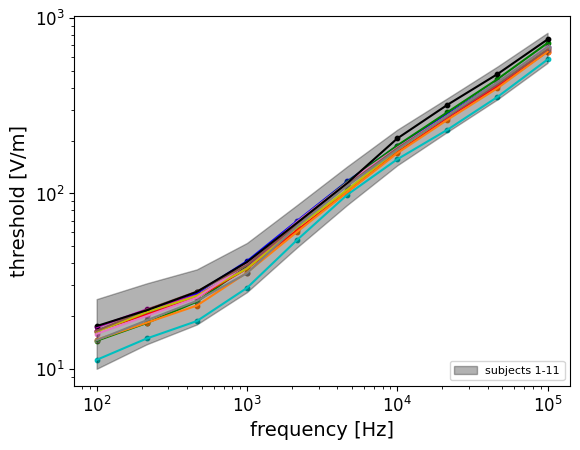

(11, 25, 3, 10, 10)
ANOVA: F_onewayResult(statistic=array([ 7.22413566,  9.38495396, 11.55062619, 15.58577753, 22.27427772,
       24.75870887, 40.90146181, 44.88758744, 45.12529352, 49.66372081]), pvalue=array([1.85117253e-11, 1.14970869e-15, 5.83270505e-20, 4.46374768e-28,
       1.12620588e-41, 9.62643839e-47, 1.27610603e-79, 1.07461421e-87,
       3.55201761e-88, 2.44441389e-97]))
(11, 25, 3, 10, 10)
subject, cell, orientation, frequency
(2, 9, 1, 0) 72.02764945012065
(6, 5, 0, 0) 69.21651955390095
(3, 8, 0, 0) 65.20015549947351
(1, 5, 2, 1) 64.66418422177296
(6, 5, 0, 1) 64.02716490830251
(825, 10)
(10,)


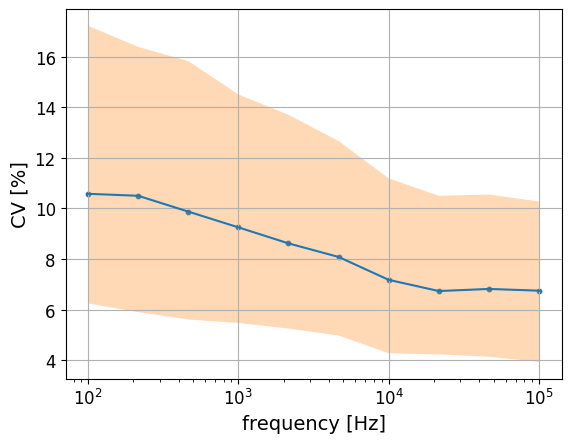

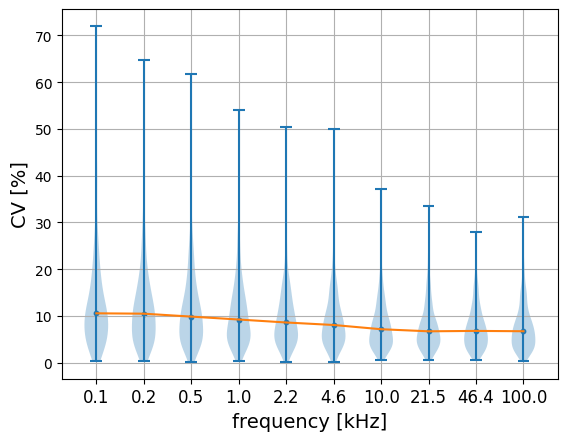

In [ ]:

"""subject variations"""

cells = [cel for cel in range(1,26)]
subjects = [3,7,12,17,18,19,20,21,22,23,24]
ages = [29,28,37,25,28,31,28,32,29,27,27]
gender = [0,1,0,1,0,0,0,1,0,1,1] #M:0, F:1
directions = ['lateral', 'superior', 'anterior']
#cells = [1,2,3,4,5,6,7,8,9,10,11,15,16,20,21,22,23,24,25] #cells[0:5] + cells[5:10] + cells[10:11] + cells[15:16] + cells[20:25] #[1,2,3,4,5], [6,7,8,9,10], [11,12,13,14,15], [16,17,18,19,20], [21,22,23,24,25]
len_loc = 10
len_freq = 10

colors = ['b','g','r','c','m','y','tab:orange','tab:pink','tab:brown','k', 'tab:gray']
#colors = ['b','y','r','g','c']
type1, type2, type3, type4, type5 = "L1 NGC-DA", "L2/3 PC", "L4 LBC", "L5 TTPC", "L6 TPC"
cell_names = [type1]*5 + [type2]*5 + [type3]*5 + [type4]*5 + [type5]*5
i = 0

all_freqs, all_threshs = np.empty((len(subjects),len(cells),len(directions),len_loc,len_freq)), np.empty((len(subjects),len(cells),len(directions),len_loc,len_freq)) #directions, locations*subjects, frequencies
#all_freqs, all_threshs = np.empty((len(cells),len(directions),len(subjects),len_loc,len_freq)), np.empty((len(cells),len(directions),len(subjects),len_loc,len_freq)) #directions, locations*subjects, frequencies


for isub, subject in enumerate(subjects):
    freqs, threshs = np.empty((len(cells),len(directions),len_loc,len_freq)), np.empty((len(cells),len(directions),len_loc,len_freq))
    for ic,cell in enumerate(cells): 
        for id,direction in enumerate(directions): 
            with open(rf"results\SPFD\interpol_linear_logspace_(10, 2, 5)_cell_nr_{cell}_dt_fact_100_subject_{subject}_direction_{direction}.pkl",'rb') as f:
                pkl = pickle.load(f)
            hs300 = pkl['hotspot_300']
            hs100k = pkl['hotspot_100k']

            if sum(hs300[0]['location']==hs100k[0]['location']) == 3:
                for iloc,val300 in enumerate(hs300.values()): #10 locations
                    freq = val300['freq']
                    thresh = val300['thresh']/np.sqrt(2) #peak->RMS
                    freqs[ic,id,iloc] = freq 
                    threshs[ic,id,iloc] = thresh
            else:
                for iloc, (val300, val100k) in enumerate(zip(hs300.values(),hs100k.values())): #10 locations
                    freq = val300['freq']
                    thresh = np.min((val300['thresh'], val100k['thresh']),axis=0)/np.sqrt(2) #peak->RMS
                    freqs[ic,id,iloc] = freq
                    threshs[ic,id,iloc] = thresh
    all_freqs[isub] = freqs #id
    all_threshs[isub] = threshs
    threshs_flat = threshs.reshape(-1,10)
    qmin = np.quantile(threshs_flat,1/4,axis=0)
    q50 = np.quantile(threshs_flat,2/4,axis=0)
    qmax = np.quantile(threshs_flat,3/4,axis=0)

    plt.scatter(freq,q50,c = colors[i],s=10)
    plt.plot(freq,q50,color = colors[i]) #,color='r'#,label=f's{i+1}'
    #plt.fill_between(freq,qmin,qmax,alpha=0.3,color = colors[i]) #,label=f'25-75 ({subject})'
    i+=1

threshs_flat = all_threshs.reshape(-1,10)
qmin = np.quantile(threshs_flat,1/4,axis=0)
q50 = np.quantile(threshs_flat,2/4,axis=0)
qmax = np.quantile(threshs_flat,3/4,axis=0)

plt.fill_between(freq,qmin,qmax,alpha=0.3,color='k',label='subjects 1-11') #,label=f'25-75 ({celltypes[ict]})'

#plot_guidelines()
plt.grid()
plt.xlabel('frequency [Hz]',fontsize = 14)
plt.ylabel('threshold [V/m]',fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.xscale('log')
plt.yscale('log')
plt.grid() 
plt.legend(loc='lower right',fontsize=8)
#plt.title(f'cells: {cells}, subjects: {subjects}, directions: {directions} exposure, 10 closest locations',fontsize=8)
plt.show()

print(all_threshs.shape)
s3 = (all_threshs[0]).reshape(-1, 10)
s7 = (all_threshs[1]).reshape(-1, 10)
s12 = (all_threshs[2]).reshape(-1, 10)
s17 = (all_threshs[3]).reshape(-1, 10)
s18 = (all_threshs[4]).reshape(-1, 10)
s19 = (all_threshs[5]).reshape(-1, 10)
s20 = (all_threshs[6]).reshape(-1, 10)
s21 = (all_threshs[7]).reshape(-1, 10)
s22 = (all_threshs[8]).reshape(-1, 10)
s23 = (all_threshs[9]).reshape(-1, 10)
s24 = (all_threshs[10]).reshape(-1, 10)



ANOVA = f_oneway(s3,s7,s12,s17,s18,s19,s20,s21,s22,s23,s24,axis=0)
print('ANOVA:',ANOVA)

"violin plots"
violin = 0
if violin:
    for fr in range(10):
        violins = []
        for i,e in enumerate([s3,s7,s12,s17,s18,s19,s20,s21,s22,s23,s24]):
            violin = e[:,fr]
            violins += [violin]
            plt.scatter(i+1,np.median(violin))
            print(f"subject: {subjects[i]}, mini: {np.min(violin)}, maxi: {np.max(violin)}, maxi/mini = {np.max(violin)/np.min(violin)}")
        maxmin = [np.max(e)/np.min(e) for e in violins]
        medians =  [np.median(e) for e in violins]
        mins = [np.min(e) for e in violins]
        print(medians)
        sorted_medians = np.argsort(medians) + 1
        sorted_mins = np.argsort(mins) + 1
        print(f"sorted medians: {sorted_medians}")
        print(f"sorted mins: {sorted_mins}")
        print(f"median_{sorted_medians[-1]}/median_{sorted_medians[0]} = {medians[np.argsort(medians)[-1]]} / {medians[np.argsort(medians)[0]]} = {medians[np.argsort(medians)[-1]] / medians[np.argsort(medians)[0]]}")
        print(f"sorted maxi/mini: {np.flip(np.argsort(maxmin))+1}")
        plt.violinplot(violins)
        plt.yscale('log')
        plt.xticks([e for e in range(12)])
        plt.grid()
        plt.title(f'frequency = {np.round(freq[fr])} Hz')
        plt.show()

"gender vs threshold"
gender = 0
if gender:
    for fr in range(10):
        violins = []
        for i,e in enumerate([s3,s7,s12,s17,s18,s19,s20,s21,s22,s23,s24]):
            violin = e[:,fr]
            violins += [violin]
            plt.scatter(gender[i],np.mean(violin))#np.max(violin)/np.min(violin)
        plt.yscale('log')
        #plt.xticks([1,2,3],['lateral','superior','anterior'])
        plt.xlabel("gender [M/F]",fontsize=12)
        plt.ylabel("threshold [V/m]",fontsize=12)
        plt.grid()
        plt.title(f'frequency = {freq[fr]} Hz')
        plt.show()

"age vs threshold"
age = 0
if age:
    for fr in range(10):
        violins = []
        for i,e in enumerate([s3,s7,s12,s17,s18,s19,s20,s21,s22,s23,s24]):
            violin = e[:,fr]
            violins += [violin]
            plt.scatter(ages[i],np.mean(violin))#np.max(violin)/np.min(violin)
        plt.yscale('log')
        #plt.xticks([1,2,3],['lateral','superior','anterior'])
        plt.xlabel("age [years]",fontsize=12)
        plt.ylabel("threshold [V/m]",fontsize=12)
        plt.grid()
        plt.title(f'frequency = {freq[fr]} Hz')
        plt.show()

"coefficient of variation for different locations"
print(all_threshs.shape)
all_CV = variation(all_threshs,axis=3)
CV = all_CV.reshape(-1,10) *100 #%
nmax = 5
argmaxima = CV.flatten().argsort()[-nmax:][::-1]
maxima = np.sort(CV.flatten())[-nmax:][::-1]
print('subject, cell, orientation, frequency')
for i in range(nmax):
    print(np.unravel_index(argmaxima[i], all_CV.shape),maxima[i])
print(CV.shape)
qmin = np.quantile(CV,1/4,axis=0)
q50 = np.quantile(CV,2/4,axis=0)
qmax = np.quantile(CV,3/4,axis=0)
print(qmin.shape)
plt.scatter(freq,q50,s=10)
plt.plot(freq,q50) #,color='r'#,label=f's{i+1}'
plt.fill_between(freq,qmin,qmax,alpha=0.3) #,label=f'25-75 ({celltypes[ict]})'
plt.grid()
plt.xlabel('frequency [Hz]',fontsize = 14)
plt.ylabel('CV [%]',fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.xscale('log')
#plt.yscale('log')
plt.show()

violins = []
for fr in range(10):
#for fr in range(25):
    #CVt = np.swapaxes(all_CV,1,3).reshape(-1,25)*100
    violins += [CV[:,fr]]
    #violins += [CVt[:,fr]]
plt.violinplot(violins)
plt.scatter([e for e in range(1,11)],q50,s=10)
plt.plot([e for e in range(1,11)],q50)
# plt.xscale('log')
plt.xticks([e for e in range(1,11)], [f'{(fre/1e3):.1f}' for fre in freq],fontsize = 12)
#plt.xticks([e for e in range(1,4)], ['lateral','superior','anterior'],fontsize = 12)
#plt.xlabel('cells',fontsize = 14)
plt.xlabel('frequency [kHz]',fontsize = 14)
plt.ylabel('CV [%]',fontsize = 14)
plt.grid()
plt.show()

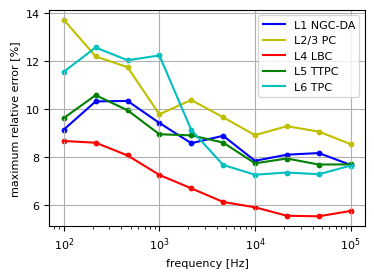

In [ ]:
"""cell variations"""

subjects = [3,7,12,17,18,19,20,21,22,23,24]
directions = ['lateral', 'superior', 'anterior']
len_loc = 10
len_freq = 10
len_celltypes = 5
len_cellclones = 5
cells = [5*celltype + cellclone + 1 for celltype in range(len_celltypes) for cellclone in range(len_cellclones)]

colors = ['b','g','r','c','m','y','tab:orange','tab:pink','tab:brown','k']
colors = ['b','y','r','g','c']
type1, type2, type3, type4, type5 = "L1 NGC-DA", "L2/3 PC", "L4 LBC", "L5 TTPC", "L6 TPC"
celltypes = [type1, type2, type3, type4, type5]
cell_names = [type1]*5 + [type2]*5 + [type3]*5 + [type4]*5 + [type5]*5
i = 0

all_freqs, all_threshs = np.empty((len_celltypes,len_cellclones,len(directions),len(subjects),len_loc,len_freq)), np.empty((len_celltypes,len_cellclones,len(directions),len(subjects),len_loc,len_freq))
all_freqs_SPFD, all_threshs_SPFD = np.empty((len_celltypes,len_cellclones,len(directions),len(subjects),len_loc,len_freq)), np.empty((len_celltypes,len_cellclones,len(directions),len(subjects),len_loc,len_freq))

for ict,celltype in enumerate(range(len_celltypes)):
    for icc,cellclone in enumerate(range(len_cellclones)):
        freqs, threshs = np.empty((len(directions),len(subjects),len_loc,len_freq)), np.empty((len(directions),len(subjects),len_loc,len_freq))
        freqs_SPFD, threshs_SPFD = np.empty((len(directions),len(subjects),len_loc,len_freq)), np.empty((len(directions),len(subjects),len_loc,len_freq))
        for id,direction in enumerate(directions):
            for isub, subject in enumerate(subjects): 
                with open(rf"results\FEM\interpol_linear_logspace_(10, 2, 5)_cell_nr_{5*celltype+cellclone+1}_dt_fact_100_subject_{subject}_direction_{direction}.pkl",'rb') as f:
                    pkl = pickle.load(f)
                with open(rf"results\SPFD\interpol_linear_logspace_(10, 2, 5)_cell_nr_{5*celltype+cellclone+1}_dt_fact_100_subject_{subject}_direction_{direction}.pkl",'rb') as f:
                    pkl_SPFD = pickle.load(f)
                hs300 = pkl['hotspot_300']
                hs100k = pkl['hotspot_100k']
                hs300_SPFD = pkl_SPFD['hotspot_300']
                hs100k_SPFD = pkl_SPFD['hotspot_100k']

                if sum(hs300[0]['location']==hs100k[0]['location']) == 3:
                    for iloc,val300 in enumerate(hs300.values()): #10 locations
                        freq = val300['freq']
                        thresh = val300['thresh']/np.sqrt(2) #peak->RMS
                        freqs[id,isub,iloc] = freq #ic,isub,iloc
                        threshs[id,isub,iloc] = thresh
                else:
                    for iloc, (val300, val100k) in enumerate(zip(hs300.values(),hs100k.values())): #10 locations
                        freq = val300['freq']
                        thresh = np.min((val300['thresh'], val100k['thresh']),axis=0)/np.sqrt(2) #peak->RMS
                        freqs[id,isub,iloc] = freq
                        threshs[id,isub,iloc] = thresh
                if sum(hs300_SPFD[0]['location']==hs100k_SPFD[0]['location']) == 3:
                    for iloc,val300_SPFD in enumerate(hs300_SPFD.values()): #10 locations
                        freq_SPFD = val300_SPFD['freq']
                        thresh_SPFD = val300_SPFD['thresh']/np.sqrt(2) #peak->RMS
                        freqs_SPFD[id,isub,iloc] = freq_SPFD #ic,isub,iloc
                        threshs_SPFD[id,isub,iloc] = thresh_SPFD
                else:
                    for iloc, (val300_SPFD, val100k_SPFD) in enumerate(zip(hs300_SPFD.values(),hs100k_SPFD.values())): #10 locations
                        freq_SPFD = val300_SPFD['freq']
                        thresh_SPFD = np.min((val300_SPFD['thresh'], val100k_SPFD['thresh']),axis=0)/np.sqrt(2) #peak->RMS
                        freqs_SPFD[id,isub,iloc] = freq_SPFD
                        threshs_SPFD[id,isub,iloc] = thresh_SPFD
        all_freqs[ict,icc] = freqs #id
        all_threshs[ict,icc] = threshs
        all_freqs_SPFD[ict,icc] = freqs_SPFD #id
        all_threshs_SPFD[ict,icc] = threshs_SPFD
    
    threshs_flat = all_threshs[ict].reshape(-1,10)
    qmin = np.quantile(threshs_flat,1/4,axis=0)
    q50 = np.quantile(threshs_flat,2/4,axis=0)
    qmax = np.quantile(threshs_flat,3/4,axis=0)

    threshs_flat_SPFD = all_threshs_SPFD[ict].reshape(-1,10)
    qmin_SPFD = np.quantile(threshs_flat_SPFD,1/4,axis=0)
    q50_SPFD = np.quantile(threshs_flat_SPFD,2/4,axis=0)
    qmax_SPFD = np.quantile(threshs_flat_SPFD,3/4,axis=0)

    i+=1



cells = [(all_threshs[0]).reshape(-1,10),(all_threshs[1]).reshape(-1,10),(all_threshs[2]).reshape(-1,10),(all_threshs[3]).reshape(-1,10),(all_threshs[4]).reshape(-1,10)]
cells_SPFD = [(all_threshs_SPFD[0]).reshape(-1,10),(all_threshs_SPFD[1]).reshape(-1,10),(all_threshs_SPFD[2]).reshape(-1,10),(all_threshs_SPFD[3]).reshape(-1,10),(all_threshs_SPFD[4]).reshape(-1,10)]

i=0
for ict,celltype in enumerate(range(len_celltypes)):
    th_diff = np.abs(cells[ict] - cells_SPFD[ict])/cells[ict]*100
    qmin_diff = np.quantile(th_diff,1/4,axis=0)
    q50_diff = np.quantile(th_diff,2/4,axis=0)
    qmax_diff = np.quantile(th_diff,3/4,axis=0)

    plt.scatter(freq_SPFD,qmax_diff,c = colors[i],s=10)
    plt.plot(freq_SPFD,qmax_diff,label=f'{celltypes[ict]}',color = colors[i]) #,color='r'
    i+=1

#plot_guidelines()
plt.xlabel('frequency [Hz]',fontsize = 8)
plt.ylabel('maximum relative error [%]',fontsize = 8)
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
plt.xscale('log')
#plt.yscale('log')
plt.legend(loc='upper right',fontsize=8)
#plt.title(f'cells: {cells}, subjects: {subjects}, directions: {directions} exposure, 10 closest locations',fontsize=8)
plt.grid()


fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.7/2,7.7*y_size/(2*x_size))
fig.tight_layout()
plt.show()